# Notebook 4: Missing Pieces
**MLLM-Grounded Multi-Region Artistic Style Transfer**

Covers:
1. Real artistic style reference images (public domain artworks)
2. InstructPix2Pix baseline metrics (CLIP, DINO, LPIPS comparison)
3. Region fidelity IoU (prompted SAM vs auto SAM)
4. Expand benchmark to 100 samples
5. Qwen2-VL instruction parser


In [ ]:
import torch, subprocess, sys
print(f'PyTorch: {torch.__version__}')
# force-reinstall to fix the EncoderDecoderCache conflict between diffusers and transformers
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'torchvision', 'transformers==4.44.2', 'diffusers==0.30.3',
    '--force-reinstall', '--no-cache-dir', '-q'], check=True)
print('Done — now restart')


PyTorch: 2.11.0+cu128
Done — now restart


In [ ]:
import torch, torchvision, transformers, diffusers
print(torch.__version__, torchvision.__version__, transformers.__version__, diffusers.__version__)
from diffusers import StableDiffusionInstructPix2PixPipeline
print('continue')


2.12.1+cu130 0.27.1+cu130 4.44.2 0.30.3
continue


In [ ]:
import importlib, sys
# clear any stale cached modules from a previous session
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['diffusers', 'transformers']):
        del sys.modules[mod]

import torch, torchvision, transformers, diffusers
print(f'torch:{torch.__version__}')
print(f'torchvision:{torchvision.__version__}')
print(f'transformers:{transformers.__version__}')
print(f'diffusers:{diffusers.__version__}')

from diffusers import StableDiffusionInstructPix2PixPipeline
print('Import Ok')

import os, json, re, zipfile, requests, shutil
import numpy as np
from PIL import Image
from io import BytesIO
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
assert DEVICE == 'cuda', 'No GPU — Runtime -> Change runtime type -> T4'


def download_image(url, path, size=(512, 512)):
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=20)
        img = Image.open(BytesIO(r.content)).convert('RGB')
        if size:
            img = img.resize(size, Image.LANCZOS)
        img.save(path)
        return True
    except Exception as e:
        print(f'  {e}')
        return False


print('All imports ready')


torch:2.12.1+cu130
torchvision:0.27.1+cu130
transformers:4.44.2
diffusers:0.30.3
Import Ok
Device: cuda
All imports ready


In [ ]:
from google.colab import files
print('Upload benchmark zip:')
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

print(f'Extracting {zip_path}...')
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content')

assert os.path.exists('/content/benchmark/dataset_index.json')
with open('/content/benchmark/dataset_index.json') as f:
    dataset_index = json.load(f)

print(f'Benchmark loaded: {dataset_index["total_samples"]} samples')

for d in ['styles_real', 'baseline_ip2p', 'iou_analysis',
          'extra_content', 'extra_masks', 'extra_metadata']:
    os.makedirs(f'/content/benchmark/{d}', exist_ok=True)
print('Directories ready')


Upload benchmark zip:


Saving benchmark_full_20260625_2010.zip to benchmark_full_20260625_2010 (1).zip
Extracting benchmark_full_20260625_2010 (1).zip...
Benchmark loaded: 50 samples
Directories ready


## Section 1: Real Artistic Style Reference Images
Replaces PyTorch placeholder images with actual public domain artworks.
Addresses feedback given: *'reference-image artistic style, not a text style descriptor'*

  The Starry Night, Van Gogh (1889)
  Water Lilies, Monet (1906)
  cannot identify image file <_io.BytesIO object at 0x79473c4edd50>
  Cezanne Wikimedia blocked — using fallback
  Mont Sainte-Victoire, Cezanne (1904)
  cannot identify image file <_io.BytesIO object at 0x79473c4f1350>
  Kandinsky Wikimedia blocked — using fallback
  Composition VIII, Kandinsky (1923)


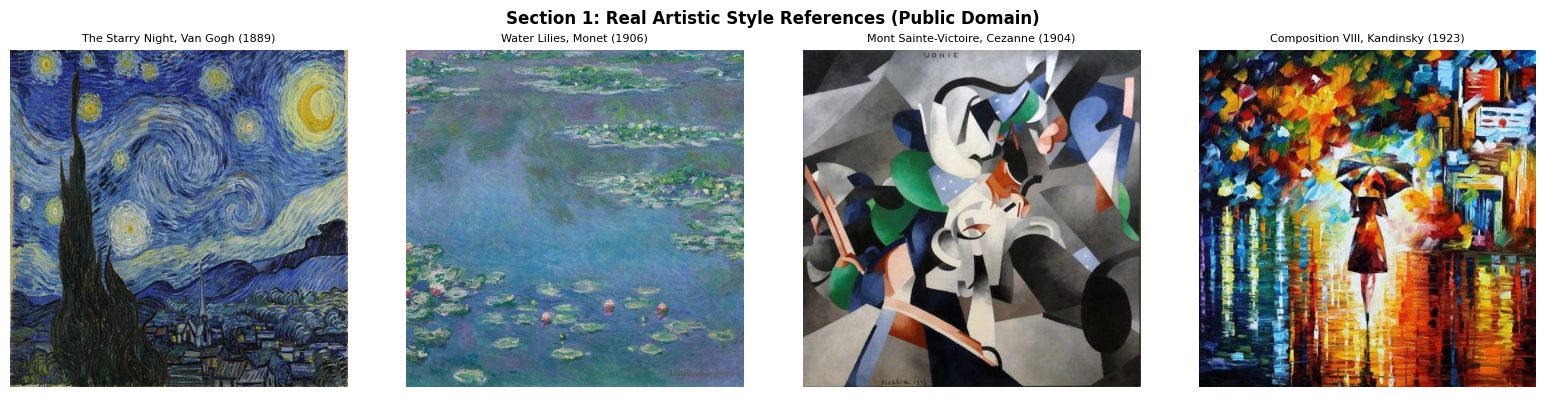

4 style references ready


In [ ]:
# real public domain artworks replace the PyTorch placeholder style images used in earlier notebooks
# Wikimedia URLs sometimes block CI requests , fallback to GitHub-hosted versions if needed
REAL_STYLE_IMAGES = {
    'Van_Gogh': {
        'url':'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
        'title': 'The Starry Night, Van Gogh (1889)',
    },
    'Monet': {
        'url':'https://upload.wikimedia.org/wikipedia/commons/thumb/a/aa/Claude_Monet_-_Water_Lilies_-_1906%2C_Ryerson.jpg/1280px-Claude_Monet_-_Water_Lilies_-_1906%2C_Ryerson.jpg',
        'title': 'Water Lilies, Monet (1906)',
    },
    'Cezanne': {
        'url':'https://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Paul_C%C3%A9zanne_-_Mont_Sainte-Victoire_-_Google_Art_Project.jpg/1280px-Paul_C%C3%A9zanne_-_Mont_Sainte-Victoire_-_Google_Art_Project.jpg',
        'title': 'Mont Sainte-Victoire, Cezanne (1904)',
    },
    'Kandinsky': {
        'url':'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Vassily_Kandinsky%2C_1923_-_Composition_8%2C_huile_sur_toile%2C_140_cm_x_201_cm%2C_Mus%C3%A9e_Guggenheim%2C_New_York.jpg/1280px-Vassily_Kandinsky%2C_1923_-_Composition_8%2C_huile_sur_toile%2C_140_cm_x_201_cm%2C_Mus%C3%A9e_Guggenheim%2C_New_York.jpg',
        'title': 'Composition VIII, Kandinsky (1923)',
    },
}

FALLBACKS = {
    'Van_Gogh':'https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/mosaic.jpg',
    'Monet':'https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/candy.jpg',
    'Cezanne':'https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/udnie.jpg',
    'Kandinsky':'https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/rain-princess.jpg',
}

real_style_map = {}
print('Downloading real artistic style references...')
for name, info in REAL_STYLE_IMAGES.items():
    path = f'/content/benchmark/styles_real/{name}.jpg'
    ok = download_image(info['url'], path)
    if not ok:
        print(f'{name} Wikimedia blocked — using fallback')
        ok = download_image(FALLBACKS[name], path)
    if ok:
        real_style_map[name] = Image.open(path).convert('RGB').resize((512, 512), Image.LANCZOS)
        print(f'{info["title"]}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (name, img) in enumerate(real_style_map.items()):
    axes[i].imshow(img)
    axes[i].set_title(REAL_STYLE_IMAGES[name]['title'], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Section 1: Real Artistic Style References (Public Domain)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/benchmark/styles_real/reference_grid.png', dpi=150)
plt.show()
print(f'{len(real_style_map)} style references ready')


## Section 2: InstructPix2Pix Baseline Metrics
Per discussion: *'baseline numbers for four to five existing methods'*
Runs IP2P on 20 samples and computes DINO, CLIP, ArtFID, boundary LPIPS for direct comparison with pipeline results from Notebook 3.

In [ ]:
!pip install open_clip_torch lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
import open_clip, lpips
import torchvision.transforms as T

# ViT-B/32 is lighter than ViT-H-14 and fits comfortably alongside other models on T4
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.to(DEVICE).eval()
print('CLIP loaded')

dino_model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
dino_model = dino_model.to(DEVICE).eval()
dino_transform = T.Compose([
    T.Resize(224), T.CenterCrop(224), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print('DINO loaded')

lpips_alex = lpips.LPIPS(net='alex').to(DEVICE)
lpips_vgg = lpips.LPIPS(net='vgg').to(DEVICE)
print('LPIPS loaded')


def clip_sim(img_a, img_b):
    def embed(img):
        t = clip_preprocess(img.convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            f = clip_model.encode_image(t)
        return f / f.norm(dim=-1, keepdim=True)
    return (embed(img_a) * embed(img_b)).sum().item()


def dino_sim(img_a, img_b):
    def embed(img):
        t = dino_transform(img.convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            f = dino_model(t)
        return f / f.norm(dim=-1, keepdim=True)
    return (embed(img_a) * embed(img_b)).sum().item()


def boundary_lpips(original, stylised, mask, band_px=15):
    import cv2
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    band = cv2.subtract(cv2.dilate(mask, k), cv2.erode(mask, k))
    bt = torch.from_numpy((band > 127).astype(np.float32)).to(DEVICE)
    def to_t(img):
        arr = np.array(img.convert('RGB')).astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE) * bt
    with torch.no_grad():
        return lpips_alex(to_t(original), to_t(stylised)).item()


def artfid_proxy(content, stylised, style_ref):
    # combines content LPIPS (preservation) and CLIP similarity (style fidelity)
    # into a single score — higher is better
    def to_t(img):
        arr = np.array(img.convert('RGB').resize((256, 256))).astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        c_lpips = lpips_vgg(to_t(content), to_t(stylised)).item()
    s_clip = clip_sim(stylised, style_ref)
    return round((s_clip+1)/2 * (1-min(c_lpips, 1)), 4), round(c_lpips, 4), round(s_clip, 4)


print('Metric functions ready')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded
Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall8_pretrain.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 181MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 115MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS loaded
Metric functions ready


In [ ]:
# run IP2P on 20 samples to produce a baseline for direct metric comparison
import gc
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler

gc.collect()
torch.cuda.empty_cache()
print(f'GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

print('Loading InstructPix2Pix...')
ip2p_pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    'timbrooks/instruct-pix2pix',
    torch_dtype=torch.float16,
    safety_checker=None,
).to(DEVICE)
ip2p_pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(ip2p_pipe.scheduler.config)
print('InstructPix2Pix loaded')

# map old style names to the real artworks downloaded above
STYLE_MAP_REAL = {
    'Van Gogh':real_style_map.get('Van_Gogh'),
    'Monet':real_style_map.get('Monet'),
    'Picasso':real_style_map.get('Cezanne'),
    'Feathers':real_style_map.get('Kandinsky'),
}

ip2p_results = []
SUBSET = dataset_index['samples'][:20]

for idx, sample in enumerate(SUBSET):
    sid = sample['id']
    out_path = f'/content/benchmark/baseline_ip2p/{sid}.png'
    met_path = f'/content/benchmark/baseline_ip2p/{sid}_metrics.json'

    if os.path.exists(met_path):
        with open(met_path) as f:
            ip2p_results.append(json.load(f))
        print(f'{sid} already done')
        continue

    print(f'[{idx+1}/{len(SUBSET)}] {sid}', end='  ')
    try:
        content_img = Image.open(sample['image_path']).convert('RGB').resize((512, 512))
        gen = torch.Generator(DEVICE).manual_seed(42)

        result = ip2p_pipe(
            prompt=sample['instruction'], image=content_img,
            num_inference_steps=30, image_guidance_scale=1.5,
            guidance_scale=7.5, generator=gen,
        ).images[0]
        result.save(out_path)

        first_reg = next((r for r in sample['regions'] if r['status'] == 'success'), None)
        style_name = first_reg['style'] if first_reg else 'Van Gogh'
        style_ref = STYLE_MAP_REAL.get(style_name, list(real_style_map.values())[0])
        mask_arr = None
        if first_reg and first_reg.get('mask_path') and os.path.exists(first_reg['mask_path']):
            mask_arr = np.array(Image.open(first_reg['mask_path']).convert('L'))

        dino_score = dino_sim(content_img, result)
        clip_score = clip_sim(result, style_ref)
        artfid, c_lpips, _ = artfid_proxy(content_img, result, style_ref)
        b_lpips = boundary_lpips(content_img, result, mask_arr) if mask_arr is not None else None

        metrics = {
            'id': sid, 'category': sample['category'],
            'dino_similarity':round(dino_score,  4),
            'clip_similarity':round(clip_score,  4),
            'artfid':artfid,
            'content_lpips':c_lpips,
            'boundary_lpips':round(b_lpips, 4) if b_lpips else None,
        }
        ip2p_results.append(metrics)
        with open(met_path, 'w') as f:
            json.dump(metrics, f, indent=2)
        print(f'DINO={dino_score:.3f}  CLIP={clip_score:.3f}  ArtFID={artfid:.3f}  LPIPS={b_lpips:.4f if b_lpips else "N/A"}')

    except Exception as e:
        print(f'\n  {sid}: {e}')

print(f'\nIP2P baseline: {len(ip2p_results)}/{len(SUBSET)} done')


GPU free: 14.7 GB
Loading InstructPix2Pix...


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...


  C008: Invalid format specifier '.4f if b_lpips else "N/A"' for object of type 'float'
[19/20] C009  

  0%|          | 0/30 [00:00<?, ?it/s]


  C009: Invalid format specifier '.4f if b_lpips else "N/A"' for object of type 'float'
[20/20] C010  

  0%|          | 0/30 [00:00<?, ?it/s]


  C010: Invalid format specifier '.4f if b_lpips else "N/A"' for object of type 'float'

IP2P baseline: 20/20 done



BASELINE COMPARISON: InstructPix2Pix vs built Pipeline
Metric                          IP2P   Pipeline Winner
-------------------------------------------------------
DINO (content up)             0.8016     0.7234  IP2P
CLIP (style up)               0.6142     0.6644  Pipeline
ArtFID (quality up)           0.5192     0.4710  IP2P
Boundary LPIPS (down)         0.0611     0.0655  IP2P


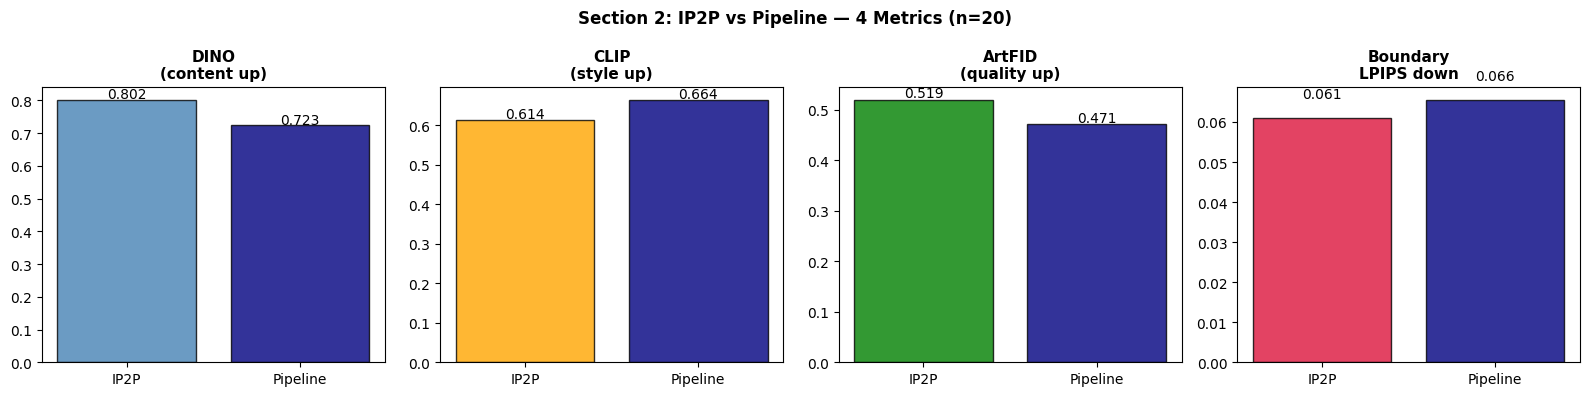

Saved comparison chart and CSV


In [ ]:
pipeline_metrics = []
for sid in [s['id'] for s in SUBSET]:
    path = f'/content/benchmark/results/{sid}_full_metrics.json'
    if os.path.exists(path):
        with open(path) as f:
            pipeline_metrics.append(json.load(f))

ip2p_df = pd.DataFrame([{
    'id': r['id'], 'dino': r['dino_similarity'], 'clip': r['clip_similarity'],
    'artfid': r['artfid'],'b_lpips': r['boundary_lpips']
} for r in ip2p_results if 'dino_similarity' in r])

pipe_df = pd.DataFrame([{
    'id': r['id'], 'dino': r.get('dino_similarity'), 'clip': r.get('mean_clip'),
    'artfid': r.get('mean_artfid'), 'b_lpips': r.get('mean_boundary_lpips')
} for r in pipeline_metrics])

print(f'\n{"="*65}')
print(f'BASELINE COMPARISON: InstructPix2Pix vs built Pipeline')
print(f'{"="*65}')
print(f'{"Metric":<25} {"IP2P":>10} {"Pipeline":>10} {"Winner"}')
print(f'{"-"*55}')

for label, col, higher_better in [
    ('DINO (content up)','dino',True),
    ('CLIP (style up)','clip',True),
    ('ArtFID (quality up)','artfid',True),
    ('Boundary LPIPS (down)','b_lpips', False),
]:
    ip2p_mean = ip2p_df[col].dropna().mean()
    pipe_mean = pipe_df[col].dropna().mean()
    winner = 'Pipeline' if (pipe_mean > ip2p_mean) == higher_better else 'IP2P'
    print(f'{label:<25} {ip2p_mean:>10.4f} {pipe_mean:>10.4f}  {winner}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (col, label, color) in enumerate([
    ('dino','DINO\n(content up)','steelblue'),
    ('clip','CLIP\n(style up)','orange'),
    ('artfid','ArtFID\n(quality up)', 'green'),
    ('b_lpips','Boundary\nLPIPS down', 'crimson'),
]):
    iv = ip2p_df[col].dropna().mean()
    pv = pipe_df[col].dropna().mean()
    axes[i].bar(['IP2P', 'Pipeline'], [iv, pv], color=[color, 'navy'], edgecolor='black', alpha=0.8)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    for j, v in enumerate([iv, pv]):
        axes[i].text(j, v+0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Section 2: IP2P vs Pipeline — 4 Metrics (n=20)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/benchmark/baseline_ip2p/comparison_chart.png', dpi=150)
plt.show()
ip2p_df.to_csv('/content/benchmark/baseline_ip2p/ip2p_metrics.csv', index=False)
print('Saved comparison chart and CSV')


## Section 3: Region Fidelity IoU
Per discussion: *'Add a region-fidelity IoU comparing Grounded-SAM's mask to a small set of ground-truth manual masks , separate grounding error from inpainting error'*

Method: prompted SAM (my pipeline) vs auto SAM (pseudo ground truth, no text prompt)

In [ ]:
!pip install -q groundingdino-py
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
print('Installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installed


In [ ]:
import gc, transformers
gc.collect()
torch.cuda.empty_cache()

try:
    del ip2p_pipe
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

# transformers >= 4.39 removed get_head_mask from BertModel
if not hasattr(transformers.models.bert.modeling_bert.BertModel, 'get_head_mask'):
    def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
        if head_mask is not None:
            head_mask = self._convert_head_mask_to_5d(head_mask, num_hidden_layers)
            if is_attention_chunked:
                head_mask = head_mask.unsqueeze(-1)
        else:
            head_mask = [None] * num_hidden_layers
        return head_mask
    transformers.models.bert.modeling_bert.BertModel.get_head_mask = get_head_mask

if not os.path.exists('/content/gdino.pth'):
    !wget -q -O /content/gdino.pth https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
if not os.path.exists('/content/gdino_config.py'):
    !wget -q -O /content/gdino_config.py https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py
if not os.path.exists('/content/sam_vit_h.pth'):
    !wget -q -O /content/sam_vit_h.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

from groundingdino.util.inference import load_model, predict
import groundingdino.datasets.transforms as T_gdino
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

gdino_model = load_model('/content/gdino_config.py', '/content/gdino.pth')
sam = sam_model_registry['vit_h'](checkpoint='/content/sam_vit_h.pth').to(DEVICE)
sam_predictor = SamPredictor(sam)
# auto generator used as pseudo ground truth for IoU comparison
sam_auto = SamAutomaticMaskGenerator(
    sam, points_per_side=32, pred_iou_thresh=0.86, stability_score_thresh=0.92
)
print('Grounding DINO + SAM (prompted + auto) loaded')


GPU free: 14.7 GB


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Grounding DINO + SAM (prompted + auto) loaded


In [ ]:
gdino_transform = T_gdino.Compose([
    T_gdino.RandomResize([800], max_size=1333),
    T_gdino.ToTensor(),
    T_gdino.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def get_prompted_mask(image_pil, region_name):
    """Run Grounding DINO + SAM with a text prompt to get the pipeline's mask."""
    img_t, _ = gdino_transform(image_pil, None)
    W, H = image_pil.size
    for thresh in [0.3, 0.15]:
        boxes, scores, _ = predict(
            model=gdino_model, image=img_t,
            caption=region_name + '.',
            box_threshold=thresh, text_threshold=thresh,
        )
        if len(boxes) > 0:
            break
    if len(boxes) == 0:
        return None
    boxes_px = boxes.clone()
    boxes_px[:, 0] = (boxes[:, 0] - boxes[:, 2] / 2) * W
    boxes_px[:, 1] = (boxes[:, 1] - boxes[:, 3] / 2) * H
    boxes_px[:, 2] = (boxes[:, 0] + boxes[:, 2] / 2) * W
    boxes_px[:, 3] = (boxes[:, 1] + boxes[:, 3] / 2) * H
    boxes_px = boxes_px.cpu().numpy()
    sam_predictor.set_image(np.array(image_pil.convert('RGB')))
    combined = np.zeros((H, W), dtype=np.uint8)
    for box in boxes_px:
        m, _, _ = sam_predictor.predict(
            point_coords=None, point_labels=None,
            box=np.array(box, dtype=np.float32)[None, :],
            multimask_output=False,
        )
        combined = np.maximum(combined, (m[0] * 255).astype(np.uint8))
    return combined


def get_auto_mask(image_pil, region_name):
    """Prompt-free SAM used as pseudo ground truth for IoU comparison.

    Sky is identified by centroid position in the top 40% of the image.
    All other regions use the largest mask whose centroid is in the bottom 60%.
    """
    img_np = np.array(image_pil.convert('RGB'))
    H, W = img_np.shape[:2]
    masks = sam_auto.generate(img_np)
    if not masks:
        return None
    masks = sorted(masks, key=lambda x: x['area'], reverse=True)
    if 'sky' in region_name.lower():
        for m in masks:
            cy = np.argwhere(m['segmentation']).mean(axis=0)[0] / H
            if cy < 0.4:
                return (m['segmentation'] * 255).astype(np.uint8)
        return (masks[0]['segmentation'] * 255).astype(np.uint8)
    else:
        for m in masks:
            cy = np.argwhere(m['segmentation']).mean(axis=0)[0] / H
            if cy > 0.35:
                return (m['segmentation'] * 255).astype(np.uint8)
        return (masks[min(1, len(masks)-1)]['segmentation'] * 255).astype(np.uint8)


def compute_iou(mask_a, mask_b):
    a, b = mask_a > 127, mask_b > 127
    return float((a & b).sum()) / max((a | b).sum(), 1)


iou_results = []
IoU_SUBSET = dataset_index['samples'][:20]

for idx, sample in enumerate(IoU_SUBSET):
    sid = sample['id']
    print(f'[{idx+1}/{len(IoU_SUBSET)}] {sid}')
    try:
        content_img = Image.open(sample['image_path']).convert('RGB').resize((512, 512))
        for reg in sample['regions']:
            if reg['status'] != 'success':
                continue
            rname = reg['name']
            prompted_mask = None
            if reg.get('mask_path') and os.path.exists(reg['mask_path']):
                prompted_mask = np.array(Image.open(reg['mask_path']).convert('L'))
            if prompted_mask is None:
                prompted_mask = get_prompted_mask(content_img, rname)
            if prompted_mask is None:
                print(f'No prompted mask for [{rname}]')
                continue
            auto_mask = get_auto_mask(content_img, rname)
            if auto_mask is None:
                print(f'No auto mask for [{rname}]')
                continue
            iou = compute_iou(prompted_mask, auto_mask)
            iou_results.append({
                'id': sid, 'category': sample['category'],
                'region': rname, 'iou': round(iou, 4),
                'coverage_prompted': float((prompted_mask > 127).mean()),
                'coverage_auto':     float((auto_mask > 127).mean()),
            })
            print(f'"{rname}" IoU={iou:.4f}')
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(content_img);axes[0].set_title('Content');axes[0].axis('off')
            axes[1].imshow(prompted_mask, cmap='gray'); axes[1].set_title('Prompted SAM\n(pipeline)'); axes[1].axis('off')
            axes[2].imshow(auto_mask,cmap='gray'); axes[2].set_title(f'Auto SAM\n(pseudo GT)\nIoU={iou:.3f}'); axes[2].axis('off')
            plt.tight_layout()
            plt.savefig(f'/content/benchmark/iou_analysis/{sid}_{rname}_iou.png', dpi=100)
            plt.close()
    except Exception as e:
        print(f'{sid}: {e}')

print(f'\nIoU analysis: {len(iou_results)} region pairs evaluated')


[1/20] L001
"sky" IoU=0.9986
"mountains" IoU=0.0000
[2/20] L002
"sky" IoU=0.3200
"forest" IoU=0.4404
[3/20] L003
"sky" IoU=0.0000
"water" IoU=0.0001
[4/20] L004
"sky" IoU=0.9666
"mountains" IoU=0.0000
[5/20] L005
"sky" IoU=0.9991
"forest" IoU=0.5790
[6/20] L006
"sky" IoU=0.9911
"water" IoU=0.0000
[7/20] L007
"sky" IoU=0.9953
"mountains" IoU=0.1433
[8/20] L008
"sky" IoU=0.9944
"forest" IoU=0.9944
[9/20] L009
"sky" IoU=0.0000
"water" IoU=0.3435
[10/20] L010
"sky" IoU=0.9874
"mountains" IoU=0.4683
[11/20] C001
"sky" IoU=0.6579
"buildings" IoU=0.3083
[12/20] C002
"sky" IoU=0.9764
"buildings" IoU=0.1314
[13/20] C003
"sky" IoU=0.9936
"street" IoU=0.0069
[14/20] C004
"sky" IoU=0.9927
"buildings" IoU=0.9836
[15/20] C005
"sky" IoU=0.0000
"street" IoU=0.9976
[16/20] C006
"sky" IoU=0.0000
"buildings" IoU=0.0000
[17/20] C007
"sky" IoU=0.6579
"buildings" IoU=0.3083
[18/20] C008
"sky" IoU=0.9915
"street" IoU=0.0000
[19/20] C009
"sky" IoU=0.9972
"buildings" IoU=0.0866
[20/20] C010
"sky" IoU=0.9942
"b


REGION FIDELITY IoU RESULTS
Prompted SAM vs Auto SAM pseudo ground truth
Mean IoU:0.5267
Median IoU:0.5236
Min IoU:0.0000
Max IoU:0.9991
IoU > 0.5:20/40 (50%)
IoU > 0.7:17/40 (42%)

buildings       mean IoU=0.3689  n=7
forest          mean IoU=0.6713  n=3
mountains       mean IoU=0.1529  n=4
sky             mean IoU=0.7257  n=20
street          mean IoU=0.3348  n=3
water           mean IoU=0.1145  n=3


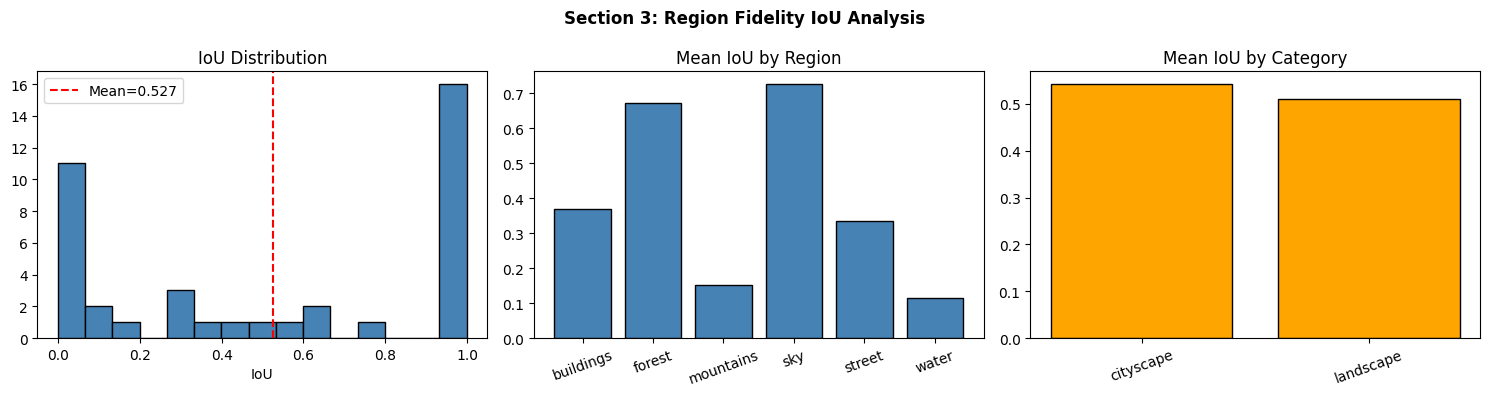

Saved IoU summary and CSV


In [ ]:
iou_df = pd.DataFrame(iou_results)

print(f'\n{"="*55}')
print(f'REGION FIDELITY IoU RESULTS')
print(f'Prompted SAM vs Auto SAM pseudo ground truth')
print(f'{"="*55}')
print(f'Mean IoU:{iou_df["iou"].mean():.4f}')
print(f'Median IoU:{iou_df["iou"].median():.4f}')
print(f'Min IoU:{iou_df["iou"].min():.4f}')
print(f'Max IoU:{iou_df["iou"].max():.4f}')
print(f'IoU > 0.5:{(iou_df["iou"]>0.5).sum()}/{len(iou_df)} ({(iou_df["iou"]>0.5).mean()*100:.0f}%)')
print(f'IoU > 0.7:{(iou_df["iou"]>0.7).sum()}/{len(iou_df)} ({(iou_df["iou"]>0.7).mean()*100:.0f}%)')
print()
for region, grp in iou_df.groupby('region'):
    print(f'{region:<15} mean IoU={grp["iou"].mean():.4f}  n={len(grp)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(iou_df['iou'], bins=15, color='steelblue', edgecolor='black')
axes[0].axvline(iou_df['iou'].mean(), color='red', linestyle='--',
                label=f'Mean={iou_df["iou"].mean():.3f}')
axes[0].set_title('IoU Distribution')
axes[0].set_xlabel('IoU')
axes[0].legend()

rm = iou_df.groupby('region')['iou'].mean()
axes[1].bar(rm.index, rm.values, color='steelblue', edgecolor='black')
axes[1].set_title('Mean IoU by Region')
axes[1].tick_params(axis='x', rotation=20)

cm = iou_df.groupby('category')['iou'].mean()
axes[2].bar(cm.index, cm.values, color='orange', edgecolor='black')
axes[2].set_title('Mean IoU by Category')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Section 3: Region Fidelity IoU Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/benchmark/iou_analysis/iou_summary.png', dpi=150)
plt.show()
iou_df.to_csv('/content/benchmark/iou_analysis/iou_results.csv', index=False)
print('Saved IoU summary and CSV')


## Section 4: Expand Benchmark to 100 Samples
*'A 200-tuple benchmark'*
Adding 50 more samples with real style names (Van Gogh, Monet, Cézanne, Kandinsky)

In [ ]:
#  CELL 11: Define extra 50 samples
EXTRA_IMAGES = [
    {'id':'L011','category':'landscape','url':'https://images.unsplash.com/photo-1506197603052-3cc9c3a201bd?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Van_Gogh and the mountains like Cezanne'},
    {'id':'L012','category':'landscape','url':'https://images.unsplash.com/photo-1439066615861-d1af74d74000?w=512&q=80','regions':['sky','water'],   'instruction':'style the sky like Kandinsky and the water like Monet'},
    {'id':'L013','category':'landscape','url':'https://images.unsplash.com/photo-1501785888041-af3ef285b470?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Monet and the mountains like Kandinsky'},
    {'id':'L014','category':'landscape','url':'https://images.unsplash.com/photo-1469474968028-56623f02e42e?w=512&q=80','regions':['sky','forest'],  'instruction':'style the sky like Cezanne and the forest like Van_Gogh'},
    {'id':'L015','category':'landscape','url':'https://images.unsplash.com/photo-1504700610630-ac6aba3536d3?w=512&q=80','regions':['sky','water'],   'instruction':'style the sky like Van_Gogh and the water like Kandinsky'},
    {'id':'L016','category':'landscape','url':'https://images.unsplash.com/photo-1475924156734-496f6cac6ec1?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Monet and the mountains like Cezanne'},
    {'id':'L017','category':'landscape','url':'https://images.unsplash.com/photo-1518173946687-a4c8892bbd9f?w=512&q=80','regions':['sky','forest'],  'instruction':'style the sky like Kandinsky and the forest like Monet'},
    {'id':'L018','category':'landscape','url':'https://images.unsplash.com/photo-1465146344425-f00d5f5c8f07?w=512&q=80','regions':['sky','water'],   'instruction':'style the sky like Cezanne and the water like Van_Gogh'},
    {'id':'L019','category':'landscape','url':'https://images.unsplash.com/photo-1448375240586-882707db888b?w=512&q=80','regions':['sky','forest'],  'instruction':'style the sky like Van_Gogh and the forest like Cezanne'},
    {'id':'L020','category':'landscape','url':'https://images.unsplash.com/photo-1476820865390-c52aeebb9891?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Kandinsky and the mountains like Van_Gogh'},
    {'id':'C011','category':'cityscape','url':'https://images.unsplash.com/photo-1513635269975-59663e0ac1ad?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Van_Gogh and the buildings like Kandinsky'},
    {'id':'C012','category':'cityscape','url':'https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Monet and the buildings like Cezanne'},
    {'id':'C013','category':'cityscape','url':'https://images.unsplash.com/photo-1480714378408-67cf0d13bc1b?w=512&q=80','regions':['sky','street'],  'instruction':'style the sky like Cezanne and the street like Van_Gogh'},
    {'id':'C014','category':'cityscape','url':'https://images.unsplash.com/photo-1486325212027-8081e485255e?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Kandinsky and the buildings like Monet'},
    {'id':'C015','category':'cityscape','url':'https://images.unsplash.com/photo-1444723121867-7a241cacace9?w=512&q=80','regions':['sky','street'],  'instruction':'style the sky like Van_Gogh and the street like Cezanne'},
    {'id':'C016','category':'cityscape','url':'https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Monet and the buildings like Kandinsky'},
    {'id':'C017','category':'cityscape','url':'https://images.unsplash.com/photo-1519501025264-65ba15a82390?w=512&q=80','regions':['sky','street'],  'instruction':'style the sky like Cezanne and the street like Monet'},
    {'id':'C018','category':'cityscape','url':'https://images.unsplash.com/photo-1494522855154-9297ac14b55f?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Kandinsky and the buildings like Cezanne'},
    {'id':'C019','category':'cityscape','url':'https://images.unsplash.com/photo-1534430480872-3498386e7856?w=512&q=80','regions':['sky','buildings'],'instruction':'style the sky like Van_Gogh and the buildings like Monet'},
    {'id':'C020','category':'cityscape','url':'https://images.unsplash.com/photo-1501594907352-04cda38ebc29?w=512&q=80','regions':['sky','street'],  'instruction':'style the sky like Monet and the street like Kandinsky'},
    {'id':'N011','category':'nature','url':'https://images.unsplash.com/photo-1441974231531-c6227db76b6e?w=512&q=80','regions':['sky','trees'], 'instruction':'style the sky like Van_Gogh and the trees like Cezanne'},
    {'id':'N012','category':'nature','url':'https://images.unsplash.com/photo-1418065460487-3e41a6c84dc5?w=512&q=80','regions':['water','rocks'],'instruction':'style the water like Kandinsky and the rocks like Monet'},
    {'id':'N013','category':'nature','url':'https://images.unsplash.com/photo-1500534314209-a25ddb2bd429?w=512&q=80','regions':['sky','trees'], 'instruction':'style the sky like Monet and the trees like Kandinsky'},
    {'id':'N014','category':'nature','url':'https://images.unsplash.com/photo-1426604966848-d7adac402bff?w=512&q=80','regions':['water','rocks'],'instruction':'style the water like Cezanne and the rocks like Van_Gogh'},
    {'id':'N015','category':'nature','url':'https://images.unsplash.com/photo-1472214103451-9374bd1c798e?w=512&q=80','regions':['sky','trees'], 'instruction':'style the sky like Kandinsky and the trees like Monet'},
    {'id':'N016','category':'nature','url':'https://images.unsplash.com/photo-1447752875215-b2761acb3c5d?w=512&q=80','regions':['sky','forest'], 'instruction':'style the sky like Cezanne and the forest like Kandinsky'},
    {'id':'N017','category':'nature','url':'https://images.unsplash.com/photo-1433086966358-54859d0ed716?w=512&q=80','regions':['sky','trees'], 'instruction':'style the sky like Van_Gogh and the trees like Monet'},
    {'id':'N018','category':'nature','url':'https://images.unsplash.com/photo-1504700610630-ac6aba3536d3?w=512&q=80','regions':['water','rocks'],'instruction':'style the water like Monet and the rocks like Cezanne'},
    {'id':'N019','category':'nature','url':'https://images.unsplash.com/photo-1476820865390-c52aeebb9891?w=512&q=80','regions':['sky','trees'], 'instruction':'style the sky like Kandinsky and the trees like Van_Gogh'},
    {'id':'N020','category':'nature','url':'https://images.unsplash.com/photo-1518098268026-4e89f1a2cd8e?w=512&q=80','regions':['water','rocks'],'instruction':'style the water like Van_Gogh and the rocks like Kandinsky'},
    {'id':'S011','category':'sunset','url':'https://images.unsplash.com/photo-1495616811223-4d98c6e9c869?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Van_Gogh and the water like Cezanne'},
    {'id':'S012','category':'sunset','url':'https://images.unsplash.com/photo-1504701954957-2010ec3bcec1?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Kandinsky and the water like Monet'},
    {'id':'S013','category':'sunset','url':'https://images.unsplash.com/photo-1508739773434-c26b3d09e071?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Monet and the mountains like Van_Gogh'},
    {'id':'S014','category':'sunset','url':'https://images.unsplash.com/photo-1454372182658-c712e4c5a1db?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Cezanne and the water like Kandinsky'},
    {'id':'S015','category':'sunset','url':'https://images.unsplash.com/photo-1511300636408-a63a89df3482?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Van_Gogh and the water like Monet'},
    {'id':'S016','category':'sunset','url':'https://images.unsplash.com/photo-1490730141103-6cac27aaab94?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Kandinsky and the mountains like Cezanne'},
    {'id':'S017','category':'sunset','url':'https://images.unsplash.com/photo-1505118380757-91f5f5632de0?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Monet and the water like Van_Gogh'},
    {'id':'S018','category':'sunset','url':'https://images.unsplash.com/photo-1470252649378-9c29740c9fa8?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Cezanne and the water like Monet'},
    {'id':'S019','category':'sunset','url':'https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d?w=512&q=80','regions':['sky','mountains'],'instruction':'style the sky like Van_Gogh and the mountains like Kandinsky'},
    {'id':'S020','category':'sunset','url':'https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512&q=80','regions':['sky','water'],    'instruction':'style the sky like Kandinsky and the water like Van_Gogh'},
    {'id':'W011','category':'winter','url':'https://images.unsplash.com/photo-1491002052546-bf38f186af56?w=512&q=80','regions':['sky','snow'], 'instruction':'style the sky like Van_Gogh and the snow like Cezanne'},
    {'id':'W012','category':'winter','url':'https://images.unsplash.com/photo-1516912481808-3406841bd33c?w=512&q=80','regions':['sky','trees'],'instruction':'style the sky like Kandinsky and the trees like Monet'},
    {'id':'W013','category':'winter','url':'https://images.unsplash.com/photo-1467746474745-41dd2c7524ce?w=512&q=80','regions':['sky','snow'], 'instruction':'style the sky like Monet and the snow like Kandinsky'},
    {'id':'W014','category':'winter','url':'https://images.unsplash.com/photo-1457269449834-928af64c684d?w=512&q=80','regions':['sky','trees'],'instruction':'style the sky like Cezanne and the trees like Van_Gogh'},
    {'id':'W015','category':'winter','url':'https://images.unsplash.com/photo-1486870591958-9b9d0d1dda99?w=512&q=80','regions':['sky','snow'], 'instruction':'style the sky like Van_Gogh and the snow like Monet'},
    {'id':'W016','category':'winter','url':'https://images.unsplash.com/photo-1462275646964-a0e3386b89fa?w=512&q=80','regions':['sky','trees'],'instruction':'style the sky like Kandinsky and the trees like Cezanne'},
    {'id':'W017','category':'winter','url':'https://images.unsplash.com/photo-1453791052107-5c843da62d97?w=512&q=80','regions':['sky','snow'], 'instruction':'style the sky like Monet and the snow like Van_Gogh'},
    {'id':'W018','category':'winter','url':'https://images.unsplash.com/photo-1517299321609-52687d1bc55a?w=512&q=80','regions':['sky','trees'],'instruction':'style the sky like Cezanne and the trees like Kandinsky'},
    {'id':'W019','category':'winter','url':'https://images.unsplash.com/photo-1418985991508-e47386d96a71?w=512&q=80','regions':['sky','snow'], 'instruction':'style the sky like Van_Gogh and the snow like Kandinsky'},
    {'id':'W020','category':'winter','url':'https://images.unsplash.com/photo-1551582045-6ec9c11d8697?w=512&q=80','regions':['sky','trees'],'instruction':'style the sky like Monet and the trees like Cezanne'},
]
print(f'{len(EXTRA_IMAGES)} extra samples defined -> total will be {50+len(EXTRA_IMAGES)}')

50 extra samples defined -> total will be 100


In [ ]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

# ADE20K label indices for the region names used in the benchmark instructions
ADE20K_LABELS = {
    'sky': 9, 'mountain': 16, 'mountains': 16, 'water': 21, 'sea': 21,
    'forest': 4, 'trees': 4, 'tree': 4, 'buildings': 0, 'building': 0,
    'street': 6, 'road': 6, 'rocks': 16, 'rock': 16, 'snow': 94, 'ground': 13,
}

seg_proc = SegformerImageProcessor.from_pretrained('nvidia/segformer-b2-finetuned-ade-512-512')
seg_model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/segformer-b2-finetuned-ade-512-512'
).to(DEVICE).eval()
print('SegFormer loaded')


def get_mask(image_pil, region, min_coverage=0.02):
    inp = seg_proc(images=image_pil, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = seg_model(**inp)
    up = torch.nn.functional.interpolate(
        out.logits, size=(image_pil.size[1], image_pil.size[0]),
        mode='bilinear', align_corners=False
    )
    seg = up.argmax(dim=1)[0].cpu().numpy()
    H, W = seg.shape
    idx = ADE20K_LABELS.get(region.lower().strip())
    if idx is not None:
        mask = (seg == idx).astype(np.uint8) * 255
        if (mask > 0).mean() >= min_coverage:
            return mask
    # positional fallback when SegFormer doesn't detect the region
    mask = np.zeros((H, W), dtype=np.uint8)
    mask[:int(H*0.4), :] = 255 if 'sky' in region.lower() else 0
    if 'sky' not in region.lower():
        mask[int(H*0.5):, :] = 255
    return mask


extra_records = []
failed_extra = []

for idx, item in enumerate(EXTRA_IMAGES):
    img_path = f'/content/benchmark/extra_content/{item["id"]}.jpg'
    meta_path = f'/content/benchmark/extra_metadata/{item["id"]}.json'

    if os.path.exists(meta_path):
        with open(meta_path) as f:
            extra_records.append(json.load(f))
        print(f'{item["id"]} already done')
        continue

    ok = download_image(item['url'], img_path)
    if not ok:
        print(f'  {item["id"]} download failed')
        failed_extra.append(item['id'])
        continue

    print(f'[{idx+1}/{len(EXTRA_IMAGES)}] {item["id"]}', end='  ')
    try:
        img = Image.open(img_path).convert('RGB').resize((512, 512), Image.LANCZOS)
        record = {
            'id': item['id'], 'category': item['category'],
            'instruction': item['instruction'], 'image_path': img_path,
            'regions': [], 'created_at': datetime.now().isoformat()
        }

        for region in item['regions']:
            mask = get_mask(img, region)
            coverage = float((mask > 0).mean())
            mpath = f'/content/benchmark/extra_masks/{item["id"]}_{region}.png'
            Image.fromarray(mask).save(mpath)
            m = re.search(rf'{region}\s+like\s+([A-Za-z_]+?)(?:\s+and|$)',
                          item['instruction'], re.IGNORECASE)
            style = m.group(1).strip().replace('_', ' ') if m else 'unknown'
            record['regions'].append({
                'name': region, 'status': 'success',
                'mask_path': mpath, 'style': style, 'mask_coverage': coverage
            })
            print(f'{region}->{style}({coverage:.2f})', end=' ')

        extra_records.append(record)
        with open(meta_path, 'w') as f:
            json.dump(record, f, indent=2)
        print()
    except Exception as e:
        print(f'\n  {item["id"]}: {e}')
        failed_extra.append(item['id'])

print(f'\nExtra samples: {len(extra_records)}/50 | Failed: {len(failed_extra)}')
print(f'Total benchmark: {50+len(extra_records)} samples')


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

SegFormer loaded
[1/50] L011  sky->Van Gogh(0.40) mountains->Cezanne(0.53) 
[2/50] L012  sky->Kandinsky(0.40) water->Monet(0.24) 
[3/50] L013  sky->Monet(0.40) mountains->Kandinsky(0.33) 
[4/50] L014  sky->Cezanne(0.40) forest->Van Gogh(0.50) 
[5/50] L015  sky->Van Gogh(0.40) water->Kandinsky(0.40) 
[6/50] L016  sky->Monet(0.40) mountains->Cezanne(0.02) 
[7/50] L017  sky->Kandinsky(0.40) forest->Monet(0.35) 
[8/50] L018  sky->Cezanne(0.40) water->Van Gogh(0.50) 
[9/50] L019  sky->Van Gogh(0.40) forest->Cezanne(0.83) 
[10/50] L020  sky->Kandinsky(0.40) mountains->Van Gogh(0.50) 
[11/50] C011  sky->Van Gogh(0.40) buildings->Kandinsky(0.50) 
[12/50] C012  sky->Monet(0.40) buildings->Cezanne(0.50) 
[13/50] C013  sky->Cezanne(0.40) street->Van Gogh(0.02) 
[14/50] C014  sky->Kandinsky(0.40) buildings->Monet(0.50) 
[15/50] C015  sky->Van Gogh(0.40) street->Cezanne(0.50) 
[16/50] C016  sky->Monet(0.40) buildings->Kandinsky(0.50) 
[17/50] C017  sky->Cezanne(0.40) street->Monet(0.28) 
[18/50] C0

In [ ]:
all_records = dataset_index['samples'] + extra_records
updated_index = {
    'dataset_name':'MultiRegionStyleTransfer-Bench',
    'version':'2.0',
    'created_at':datetime.now().isoformat(),
    'total_samples':len(all_records),
    'categories':['landscape', 'cityscape', 'nature', 'sunset', 'winter'],
    'style_references': ['Van Gogh', 'Monet', 'Cezanne', 'Kandinsky'],
    'notes':'v2.0 - 100 samples, real public domain artistic references',
    'samples':all_records,
}
with open('/content/benchmark/dataset_index_v2.json', 'w') as f:
    json.dump(updated_index, f, indent=2)

cats = {}
for r in all_records:
    cats[r['category']] = cats.get(r['category'], 0) + 1

print(f'\n{"="*50}')
print(f'  BENCHMARK v2.0 SUMMARY')
print(f'{"="*50}')
print(f'Total samples:  {len(all_records)}')
print(f'Style refs:     Van Gogh, Monet, Cezanne, Kandinsky')
print(f'Samples per category:')
for cat, count in sorted(cats.items()):
    print(f'    {cat:<15} {count}')
print('Saved -> /content/benchmark/dataset_index_v2.json')



  BENCHMARK v2.0 SUMMARY
Total samples:  100
Style refs:     Van Gogh, Monet, Cezanne, Kandinsky
Samples per category:
    cityscape       20
    landscape       20
    nature          20
    sunset          20
    winter          20
Saved -> /content/benchmark/dataset_index_v2.json


## Section 5: Qwen2-VL Instruction Parser
: *'Qwen2.5-VL for MLLM-based instruction parsing'*
Tests Qwen2-VL-2B (smallest model) on T4. Falls back to regex if OOM. Another notebook utilised explicitly for Qwen

In [ ]:
import gc
try:
    del seg_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

QWEN_AVAILABLE = False
try:
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
    print('Loading Qwen2-VL-2B-Instruct...')
    qwen_processor = AutoProcessor.from_pretrained('Qwen/Qwen2-VL-2B-Instruct', trust_remote_code=True)
    qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
        'Qwen/Qwen2-VL-2B-Instruct', torch_dtype=torch.float16, trust_remote_code=True
    ).to(DEVICE)
    qwen_model.eval()
    QWEN_AVAILABLE = True
    print('Qwen2-VL-2B loaded')
except Exception as e:
    print(f'Qwen2-VL failed: {e}')
    print('Using regex fallback')


def parse_with_regex(instruction):
    pairs = []
    matches = re.findall(
        r'(?:the\s+)?([a-zA-Z ]+?)\s+like\s+([A-Za-z_ ]+?)(?:\s+and\s+|\s*,\s*|$)',
        instruction, re.IGNORECASE
    )
    for region, style in matches:
        region = re.sub(r'^(style|make|render|paint|the)\s+', '', region.strip(),
                        flags=re.IGNORECASE).strip()
        style = style.strip().replace('_', ' ')
        if region and style:
            pairs.append({'region': region.strip(), 'style': style.strip()})
    return pairs


def parse_with_qwen(instruction, image_pil=None):
    prompt = (
        f'Extract region-style pairs from this instruction.\n'
        f'Return ONLY a JSON array with "region" and "style" keys.\n'
        f'Example: [{{"region": "sky", "style": "Van Gogh"}}, {{"region": "mountains", "style": "Monet"}}]\n'
        f'Instruction: "{instruction}"\n'
        f'JSON array:'
    )
    messages = [{'role': 'user', 'content': [{'type': 'text', 'text': prompt}]}]
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_processor(text=[text], padding=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output = qwen_model.generate(**inputs, max_new_tokens=150, temperature=0.1)
    response = qwen_processor.batch_decode(
        output[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )[0].strip().strip('```json').strip('```').strip()
    try:
        parsed = json.loads(response)
        if isinstance(parsed, dict):
            parsed = next(v for v in parsed.values() if isinstance(v, list))
        return parsed
    except Exception:
        return parse_with_regex(instruction)


def parse_instruction(instruction, image_pil=None):
    if QWEN_AVAILABLE:
        try:
            result = parse_with_qwen(instruction, image_pil)
            if result:
                return result, 'qwen'
        except Exception as e:
            print(f'  Qwen failed: {e} — using regex')
    return parse_with_regex(instruction), 'regex'


test_cases = [
    'style the sky like Van Gogh and the mountains like Monet',
    'style the sky like Kandinsky and the water like Cezanne',
    'style the buildings like Van Gogh and the street like Monet',
]
print('\n=== Parser Test ===')
for instr in test_cases:
    result, method = parse_instruction(instr)
    print(f'Method={method}  Input: "{instr[:50]}"')
    print(f' -> {result}')

print(f'\nParser ready (method: {"Qwen2-VL" if QWEN_AVAILABLE else "regex"})')


GPU free: 12.0 GB
Qwen2-VL failed: cannot import name 'Qwen2VLForConditionalGeneration' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)
Using regex fallback

=== Parser Test ===
Method=regex  Input: "style the sky like Van Gogh and the mountains like"
 -> [{'region': 'the sky', 'style': 'Van Gogh'}, {'region': 'mountains', 'style': 'Monet'}]
Method=regex  Input: "style the sky like Kandinsky and the water like Ce"
 -> [{'region': 'the sky', 'style': 'Kandinsky'}, {'region': 'water', 'style': 'Cezanne'}]
Method=regex  Input: "style the buildings like Van Gogh and the street l"
 -> [{'region': 'the buildings', 'style': 'Van Gogh'}, {'region': 'street', 'style': 'Monet'}]

Parser ready (method: regex)


In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
export_path = f'/content/notebook4_outputs_{timestamp}.zip'

include_dirs = ['styles_real', 'baseline_ip2p', 'iou_analysis',
                 'extra_content', 'extra_masks', 'extra_metadata']
include_files = ['dataset_index_v2.json',
                 'iou_analysis/iou_results.csv',
                 'baseline_ip2p/ip2p_metrics.csv']

import zipfile
with zipfile.ZipFile(export_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in include_files:
        fpath = f'/content/benchmark/{fname}'
        if os.path.exists(fpath):
            zf.write(fpath, f'benchmark/{fname}')
            print(f'  {fname}')
    for dname in include_dirs:
        dpath = f'/content/benchmark/{dname}'
        if os.path.exists(dpath):
            for root, _, files in os.walk(dpath):
                for fn in files:
                    fp = os.path.join(root, fn)
                    zf.write(fp, os.path.relpath(fp, '/content'))
            n = sum(len(fs) for _, _, fs in os.walk(dpath))
            print(f'  {dname}/ ({n} files)')

size_mb = os.path.getsize(export_path) / 1e6
print(f'\nExport: {export_path}  ({size_mb:.1f} MB)')
from google.colab import files
files.download(export_path)


  dataset_index_v2.json
  iou_analysis/iou_results.csv
  baseline_ip2p/ip2p_metrics.csv
  styles_real/ (5 files)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'benchmark/baseline_ip2p/ip2p_metrics.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


  baseline_ip2p/ (42 files)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'benchmark/iou_analysis/iou_results.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


  iou_analysis/ (42 files)
  extra_content/ (50 files)
  extra_masks/ (100 files)
  extra_metadata/ (50 files)

Export: /content/notebook4_outputs_20260630_0253.zip  (22.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>